# Visualisation of MBTI Class Ditributions

In [2]:
from datasets import concatenate_datasets, load_dataset
import pandas as pd

In [4]:
dataset = load_dataset("DrinkIcedT/mbti_unbalanced")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['post', 'labels', 'I', 'N', 'F', 'P'],
        num_rows: 43266
    })
    test: Dataset({
        features: ['post', 'labels', 'I', 'N', 'F', 'P'],
        num_rows: 5460
    })
    validation: Dataset({
        features: ['post', 'labels', 'I', 'N', 'F', 'P'],
        num_rows: 5396
    })
})


In [ ]:
# merge the splits
# create a list of the splits
splits_to_merge = []
for split_name in ["train", "test", "val"]:
        splits_to_merge.append(dataset[split_name])

# concatanate split list
combined_dataset = concatenate_datasets(splits_to_merge)

# convert to pandas df
df = combined_dataset.to_pandas()

# extracting true labels
label_feature = combined_dataset.features["labels"]

# map true labels to numbers in dimension cols
df['labels_text'] = df['labels'].apply(lambda x: label_feature.int2str(x))

# counting class occurences and calculating percentages for MBTI labels
labels_pct = df['labels_text'].value_counts(normalize=True) * 100

tabelle_labels = pd.DataFrame({
    'Merkmal / Klasse': [f'MBTI: {kategorie}' for kategorie in labels_pct.index],
    'Prozentanteil (%)': labels_pct.values
})

# counting class occurences and calculating percentages of dimensions
binaere_spalten = ['I', 'N', 'F', 'P']
bin_pct = df[binaere_spalten].mean() * 100

tabelle_binaer = pd.DataFrame({
    'Merkmal / Klasse': [f'Spalte {spalte} (Anteil der 1en)' for spalte in bin_pct.index],
    'Prozentanteil (%)': bin_pct.values
})

# put together
ergebnis_tabelle = pd.concat([tabelle_labels, tabelle_binaer], ignore_index=True)
ergebnis_tabelle['Prozentanteil (%)'] = ergebnis_tabelle['Prozentanteil (%)'].round(2)

print(ergebnis_tabelle)

             Merkmal / Klasse  Prozentanteil (%)
0                  MBTI: INFP              21.28
1                  MBTI: INFJ              17.43
2                  MBTI: INTP              14.76
3                  MBTI: INTJ              12.33
4                  MBTI: ENFP               7.98
5                  MBTI: ENTP               7.83
6                  MBTI: ISTP               3.76
7                  MBTI: ISFP               3.01
8                  MBTI: ENTJ               2.65
9                  MBTI: ISTJ               2.33
10                 MBTI: ENFJ               2.25
11                 MBTI: ISFJ               1.95
12                 MBTI: ESTP               0.98
13                 MBTI: ESFJ               0.51
14                 MBTI: ESFP               0.50
15                 MBTI: ESTJ               0.45
16  Spalte I (Anteil der 1en)              76.85
17  Spalte N (Anteil der 1en)              86.51
18  Spalte F (Anteil der 1en)              54.91
19  Spalte P (Anteil

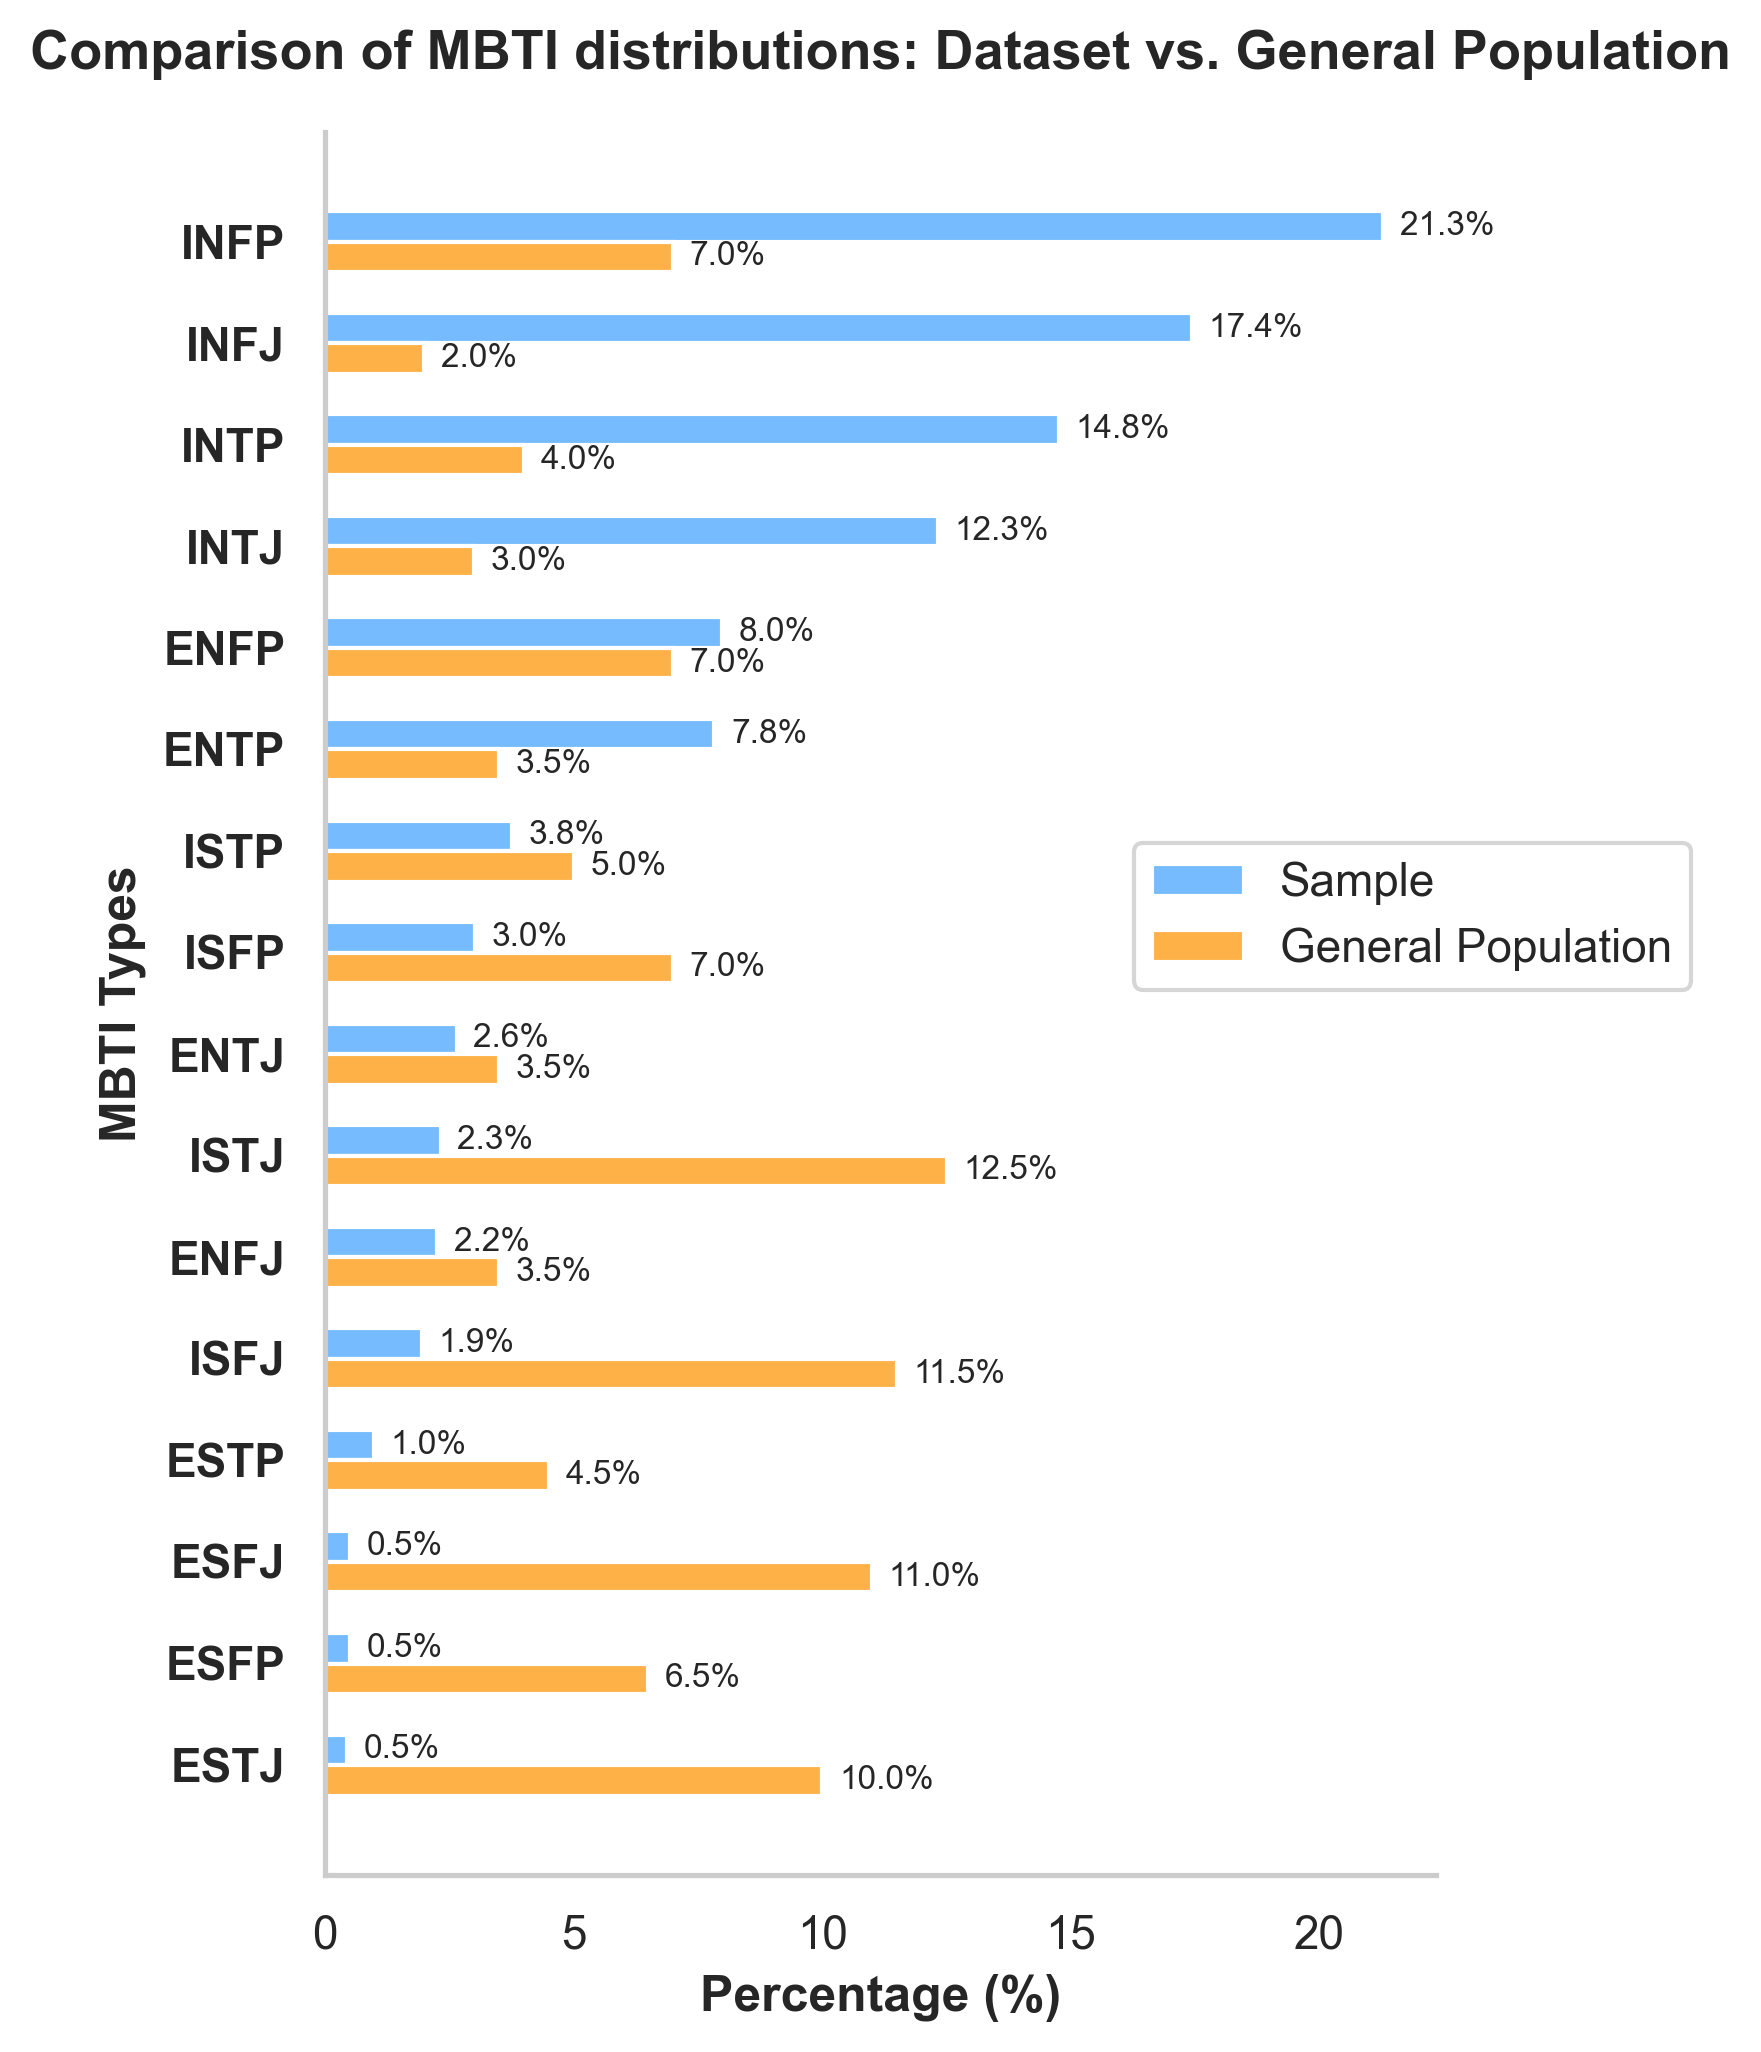

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# preparing sample data
sample_data = {
    "INFP": 21.28, "INFJ": 17.43, "INTP": 14.76, "INTJ": 12.33,
    "ENFP": 7.98,  "ENTP": 7.83,  "ISTP": 3.76,  "ISFP": 3.01,
    "ENTJ": 2.65,  "ISTJ": 2.33,  "ENFJ": 2.25,  "ISFJ": 1.95,
    "ESTP": 0.98,  "ESFJ": 0.51,  "ESFP": 0.50,  "ESTJ": 0.45,
}

# preparing general population data
pop_data = {
    "INFP": 7.0,  "INFJ": 2.0,  "INTP": 4.0,  "INTJ": 3.0,
    "ENTP": 3.5,  "ENFP": 7.0,  "ISTP": 5.0,  "ISFP": 7.0,
    "ENTJ": 3.5,  "ISTJ": 12.5, "ENFJ": 3.5,  "ISFJ": 11.5,
    "ESTP": 4.5,  "ESFP": 6.5,  "ESFJ": 11.0, "ESTJ": 10.0,
}

# put in one df
df_compare = pd.DataFrame(
    {
        "Sample (Datensatz)": pd.Series(sample_data),
        "Allgemeinbevölkerung": pd.Series(pop_data),
    }
)

# sorting based on sample data
df_compare = df_compare.sort_values(by="Sample (Datensatz)", ascending=True)

# create plot
fig, ax = plt.subplots(figsize=(5, 7), dpi=300)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(False)

y = np.arange(len(df_compare))  # positions on y-axis
height = 0.30  # bar width

# bars
rects1 = ax.barh(
    y + height / 2,
    df_compare["Sample (Datensatz)"],
    height,
    label="Sample",
    color="#75bbfd",
)
rects2 = ax.barh(
    y - height / 2,
    df_compare["Allgemeinbevölkerung"],
    height,
    label="General Population",
    color="#fdb147",
)

# axis labels
ax.set_xlabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_ylabel("MBTI Types", fontsize=12, fontweight="bold")
ax.set_title(
    "Comparison of MBTI distributions: Dataset vs. General Population",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_yticks(y)
ax.set_yticklabels(df_compare.index, fontsize=11, fontweight="bold")

# legend etc

legend = ax.legend(fontsize=11, frameon=True, loc="center right", bbox_to_anchor=(1.25, 0.55))
legend.set_in_layout(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# percentage labels
def autolabel_horizontal(rects):
    for rect in rects:
        width = rect.get_width()
        ax.annotate(
            f"{width:.1f}%",
            xy=(width, rect.get_y() + rect.get_height() / 2),
            xytext=(4, 0),  # 4 Punkte Versatz nach rechts
            textcoords="offset points",
            ha="left",  # Links am Textpunkt ausrichten
            va="center",
            fontsize=8,
        )

autolabel_horizontal(rects1)
autolabel_horizontal(rects2)

plt.tight_layout()
plt.savefig("../figs/mbti_vergleich_horizontal.png", dpi=300, bbox_inches='tight')
plt.show()